# Late Procurement Deliveries – Notebook Workflow

## 1. Import Libraries and Set Variables
- Import `pandas` for data manipulation, `numpy` for numerical operations
- Import `scikit-learn` modules for machine learning models, evaluation metrics, and visualization
- Import `matplotlib.pyplot` for creating visualizations
- Set random seed variable for reproducibility

## 2. Read Data
- Load Excel files for suppliers, materials, warehouses, and procurement transactions
- Add prefixes to column names to identify source tables
- Combine transaction parts into a single DataFrame using merge on the `id` column

## 3. Data Preparation
- Merge supplier information with transaction data
- Create target variable `late` by comparing requested and received dates
- Generate dummy variables for categorical features (supplier, material, warehouse codes)
- Define numeric and categorical features for modeling
- Remove rows with missing values in features
- Split data into training (80%) and test (20%) sets

## 4. Decision Tree Modeling
- Create a decision tree classifier with controlled complexity (max_depth=3)
- Train the model on the training data
- Visualize the decision tree structure with feature names and class labels
- Evaluate model performance using confusion matrix and metrics
- Experiment with tree depth to demonstrate overfitting

## 5. Random Forest Modeling
- Build a Random Forest ensemble with 100 trees and controlled depth
- Visualize sample trees from the ensemble
- Compare performance metrics with the decision tree model
- Analyze the impact of ensemble size on model accuracy

## 6. Gradient Boosted Trees Modeling
- Implement Gradient Boosting with optimized parameters
- Evaluate performance with confusion matrix and standard metrics
- Explore the relationship between number of boosting iterations and model accuracy
- Compare results with decision tree and random forest models

## 7. Model Evaluation
- Calculate and compare accuracy, precision, recall, and F1-score for all models
- Visualize performance metrics and confusion matrices
- Analyze overfitting behavior with training vs. testing accuracy plots
- Identify optimal model configurations

## 1. Import Libraries

In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from matplotlib import pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score,                              
                             f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)


Get the current working directory

Set variables


In [3]:
random_var=2025

## 2. Read Data

In [4]:
path_to_files = "https://raw.github.com/jan-source/course_business_analytics_students/main/teaching_cases/case_2_bi_report/data"

Get supplier data

In [5]:
supplier = pd.read_excel(f'{path_to_files}/supplier.xlsx')

Get the column names

In [6]:
supplier.columns

Index(['id', 'name', 'group', 'country', 'street', 'house_number', 'city',
       'postal_code', 'email'],
      dtype='object')

Show the first rows of data

In [7]:
supplier.head()

,id,name,group,country,street,house_number,city,postal_code,email
0,1,Beans Inc.,raw material,Mexico,Broadway Ave,150,New York,10012,info@beansinc.com
1,2,Aromatico,raw material,Italy,Kaffeegasse,27,Bremen,28195,kontakt@aromatico.de
2,3,Farmers of Brazil,raw material,Brazil,Rua do Cafe,72,Sao Paulo,04567-000,contact@farmersofbrazil.br
3,4,Fair Trade AG,raw material,Panama,Friedensstra√üe,10,Zuerich,8001,service@fairtradeag.ch
4,5,Handelskontor Hamburg,raw material,Germany,Speicherstra√üe,3,Hamburg,20457,info@handelskontor.de


Add a suffix to remember from excel file data was read

In [8]:
supplier = pd.read_excel(f'{path_to_files}/supplier.xlsx').add_prefix('supplier_')

Get material data

In [9]:
material = pd.read_excel(f'{path_to_files}/material.xlsx').add_prefix('material_')

Get warehouse data

In [10]:
warehouse = pd.read_excel(f'{path_to_files}/warehouse.xlsx').add_prefix('warehouse_')

Get transaction data

In [11]:
transactions_part_a = pd.read_excel(f'{path_to_files}/procurement_transactions_part_a.xlsx')

In [12]:
transactions_part_b = pd.read_excel(f'{path_to_files}/procurement_transactions_part_b.xlsx')

Check output for transactions part_a

In [13]:
transactions_part_a.head()

,supplier_code,material_code,warehouse_code,logistic_partner_code,id
0,14,c_2,2,6,be97db17-13c5-45b0-a874-4ec09e3333f3
1,14,c_2,7,6,d1f81ead-a36c-4aa2-af6d-19e29a2472ad
2,10,c_2,4,6,85f25b81-292a-4097-8d87-6f1b57315ed3
3,4,c_0,6,6,7fa2cf28-23a3-4029-aa47-d9d4bbc8570b
4,4,c_0,3,6,48207d3f-134c-4703-a425-61b2f08c65fa


## 3. Data Preparation

### Combine transactions together
use a Left-Join to combine both dataframes via the column ID

In [14]:
transactions = pd.merge(transactions_part_a, transactions_part_b, on='id')

In [15]:
transactions.head()

,supplier_code,material_code,warehouse_code,logistic_partner_code,id,order_date,requested_date,received_date,quantity,price
0,14,c_2,2,6,be97db17-13c5-45b0-a874-4ec09e3333f3,2020-06-05,2020-06-15,2020-06-20 07:00:00,750,3.742660
1,14,c_2,7,6,d1f81ead-a36c-4aa2-af6d-19e29a2472ad,2023-12-28,2024-01-09,2024-01-10 03:00:00,750,7.382834
2,10,c_2,4,6,85f25b81-292a-4097-8d87-6f1b57315ed3,2020-09-07,2020-09-26,2020-09-30 04:00:00,250,5.038926
3,4,c_0,6,6,7fa2cf28-23a3-4029-aa47-d9d4bbc8570b,2023-03-30,2023-04-17,2023-04-16 01:00:00,500,43.626411
4,4,c_0,3,6,48207d3f-134c-4703-a425-61b2f08c65fa,2020-03-29,2020-04-17,2020-04-16 07:00:00,250,30.163969


### Add Supplier Info

In [16]:
transactions = pd.merge(transactions, supplier, left_on='supplier_code', right_on='supplier_id', how='left')

In [17]:
transactions.columns

Index(['supplier_code', 'material_code', 'warehouse_code',
       'logistic_partner_code', 'id', 'order_date', 'requested_date',
       'received_date', 'quantity', 'price', 'supplier_id', 'supplier_name',
       'supplier_group', 'supplier_country', 'supplier_street',
       'supplier_house_number', 'supplier_city', 'supplier_postal_code',
       'supplier_email'],
      dtype='object')

### Calculate whether a delivery was late

In [18]:
transactions['received_date'] = transactions['received_date'].dt.date

In [19]:
transactions['late'] = transactions['requested_date'] < transactions['received_date']

#### Check Supplier

In [20]:
transactions.groupby('supplier_name')['late'].mean().sort_values(ascending=False)

supplier_name
Origin Lineage Trading      0.980198
TerraBean Source Co.        0.638360
RoastWorks Supply Co.       0.583578
Farmers of Brazil           0.436782
Green Bean Collective       0.420712
The Bean Curators           0.409722
Humble Roots Trading Co.    0.402556
Small Batch Supply          0.390390
Equator Supply Network      0.368771
Aromatico                   0.230346
Grindline Partners          0.227957
Craft Roast Co-Op           0.219978
Handelskontor Hamburg       0.218501
Fair Trade AG               0.212598
Beans Inc.                  0.198189
Name: late, dtype: float64

get column names of transactions

In [21]:
transactions.columns

Index(['supplier_code', 'material_code', 'warehouse_code',
       'logistic_partner_code', 'id', 'order_date', 'requested_date',
       'received_date', 'quantity', 'price', 'supplier_id', 'supplier_name',
       'supplier_group', 'supplier_country', 'supplier_street',
       'supplier_house_number', 'supplier_city', 'supplier_postal_code',
       'supplier_email', 'late'],
      dtype='object')

### Create Dummy Variables

In [22]:
transactions_with_dummies = pd.get_dummies(transactions, columns=['supplier_code', 'material_code', 'warehouse_code'])

#### Define the features (x-Variables)

In [23]:

features = (['quantity', 'price'] + 
            [col for col in transactions_with_dummies.columns if col.startswith('supplier_code_')] +
            [col for col in transactions_with_dummies.columns if col.startswith('material_code_')] + 
            [col for col in transactions_with_dummies.columns if col.startswith('warehouse_code_')]            
            )

In [24]:
features

['quantity',
 'price',
 'supplier_code_1',
 'supplier_code_2',
 'supplier_code_3',
 'supplier_code_4',
 'supplier_code_5',
 'supplier_code_6',
 'supplier_code_7',
 'supplier_code_8',
 'supplier_code_9',
 'supplier_code_10',
 'supplier_code_11',
 'supplier_code_12',
 'supplier_code_13',
 'supplier_code_14',
 'supplier_code_15',
 'material_code_c_0',
 'material_code_c_1',
 'material_code_c_2',
 'material_code_c_3',
 'material_code_c_4',
 'material_code_c_5',
 'material_code_c_6',
 'material_code_c_7',
 'warehouse_code_1',
 'warehouse_code_2',
 'warehouse_code_3',
 'warehouse_code_4',
 'warehouse_code_5',
 'warehouse_code_6',
 'warehouse_code_7']

#### Clean Data for missing values

In [25]:
transactions_with_dummies.dropna(subset=features, inplace=True)

### Test / Train split


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    transactions_with_dummies[features], 
    transactions_with_dummies['late'],
    test_size=0.2, 
    random_state=random_var
)

### 4. Decision Tree Modeling

#### Initialize a decision tree with a maximum of 3-levels

In [27]:
tree = DecisionTreeClassifier(max_depth=3, random_state=random_var)


#### 
Fit tree on the data

In [28]:
tree.fit(X=X_train, y=y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2025
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


Visualize the decision tree


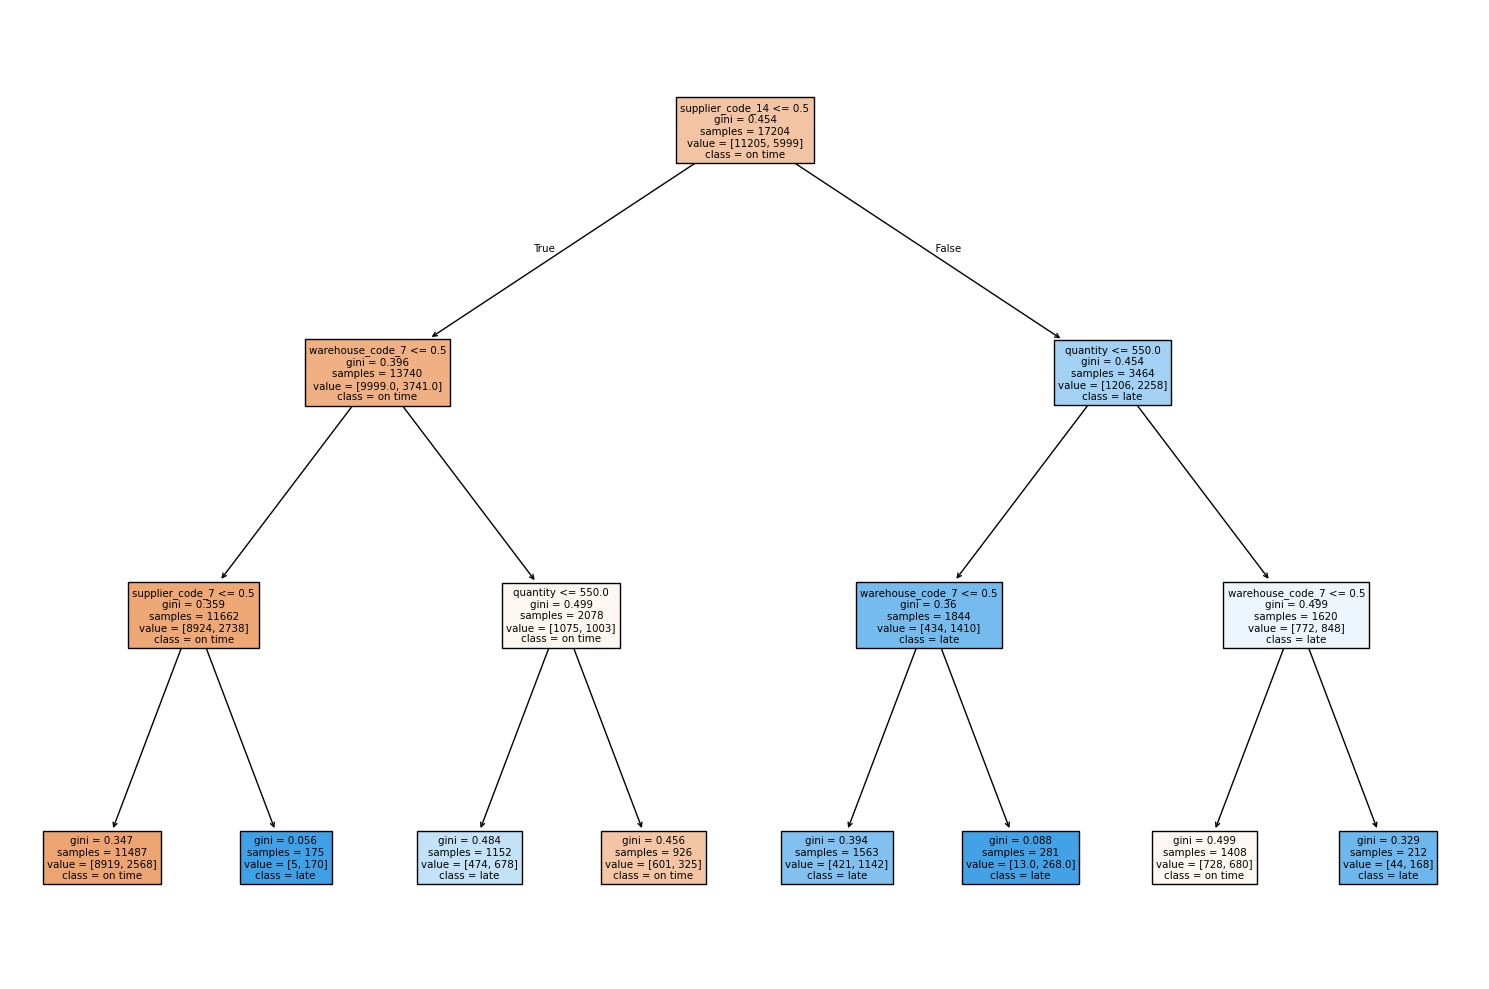

In [29]:
plt.figure(figsize=(15, 10))
plot_tree(
        tree, feature_names=features, 
        class_names=['on time', 'late'], 
        filled=True
        )
plt.tight_layout()
plt.savefig('decision_tree_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Model Evaluation

### Get Accuracy of the decision tree

In [30]:
# Calculate predictions for test and train sets
y_pred_test = tree.predict(X_test)
y_pred_train = tree.predict(X_train)



get the confusion matrix for the test dataset

In [31]:
cm = confusion_matrix(y_test, y_pred_test, labels=[1, 0])

Transpose the confusion matrix to invert the axes (same order as in lecture notes)

In [32]:
cm_transposed = cm.T

Display the confusion matrix

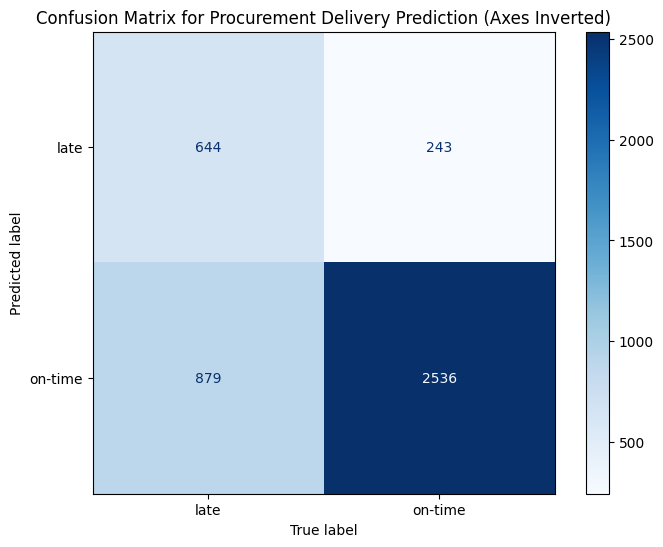

In [33]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_transposed, 
                             display_labels=['late', 'on-time'])

# Create a figure and plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.xlabel('True label')  # This will now be on the x-axis
plt.ylabel('Predicted label')  # This will now be on the y-axis
plt.title('Confusion Matrix for Procurement Delivery Prediction (Axes Inverted)')
plt.show()

Accuracy: What percentage of the model's predictions were correct?

In [34]:
accuracy_score(y_true=y_test, y_pred=y_pred_test)

0.7391910739191074

Precision: Out of all the positive predictions (delivery is late), how many were actually correct?


In [35]:
precision_score(y_true=y_test, y_pred=y_pred_test)

0.7260428410372041

Recall: Of all the actual positive instances, how many did the model correctly identify? 


In [36]:
recall_score(y_true=y_test, y_pred=y_pred_test)

0.42284963887065

Calculate Specificity: Of all the actual negative instances (delivery is on time), how many did the model correctly identify?


In [37]:
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)


In [38]:
specificity

np.float64(0.42284963887065)

Beautified Output

In [39]:
print(f"Specificity: {specificity:.2f}")

Specificity: 0.42


F-1 Score

In [40]:
f1_score(y_true=y_test, y_pred=y_pred_test)

0.5344398340248963

## Generate overfited tree

In [41]:
tree_overfitted = DecisionTreeClassifier(max_depth=40, random_state=random_var)

In [42]:
tree_overfitted.fit(X=X_train, y=y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,40
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,2025
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [43]:
# Calculate predictions for test and train sets
y_pred_test = tree_overfitted.predict(X_test)
y_pred_train = tree_overfitted.predict(X_train)

In [44]:
accuracy_score(y_true=y_test, y_pred=y_pred_test)

0.6980474198047419

In [45]:
accuracy_score(y_true=y_train, y_pred=y_pred_train)

0.9934898860730063

#### Simulate overfitting for different depths

In [46]:
for i in range(3, 30):
    tree_overfitted = DecisionTreeClassifier(max_depth=i, random_state=random_var)
    tree_overfitted.fit(X=X_train, y=y_train)
    
    y_pred_test = tree_overfitted.predict(X_test)
    y_pred_train = tree_overfitted.predict(X_train)
    
    print(f"Max depth: {i}, Test accuracy: {accuracy_score(y_true=y_test, y_pred=y_pred_test):.2f}, Train accuracy: {accuracy_score(y_true=y_train, y_pred=y_pred_train):.2f}")

Max depth: 3, Test accuracy: 0.74, Train accuracy: 0.74
Max depth: 4, Test accuracy: 0.74, Train accuracy: 0.74
Max depth: 5, Test accuracy: 0.75, Train accuracy: 0.75
Max depth: 6, Test accuracy: 0.74, Train accuracy: 0.76
Max depth: 7, Test accuracy: 0.75, Train accuracy: 0.76
Max depth: 8, Test accuracy: 0.75, Train accuracy: 0.77
Max depth: 9, Test accuracy: 0.75, Train accuracy: 0.78
Max depth: 10, Test accuracy: 0.75, Train accuracy: 0.79
Max depth: 11, Test accuracy: 0.75, Train accuracy: 0.80
Max depth: 12, Test accuracy: 0.75, Train accuracy: 0.82
Max depth: 13, Test accuracy: 0.75, Train accuracy: 0.83
Max depth: 14, Test accuracy: 0.74, Train accuracy: 0.85
Max depth: 15, Test accuracy: 0.74, Train accuracy: 0.87
Max depth: 16, Test accuracy: 0.73, Train accuracy: 0.89
Max depth: 17, Test accuracy: 0.73, Train accuracy: 0.90
Max depth: 18, Test accuracy: 0.73, Train accuracy: 0.92
Max depth: 19, Test accuracy: 0.72, Train accuracy: 0.93
Max depth: 20, Test accuracy: 0.71, Tr

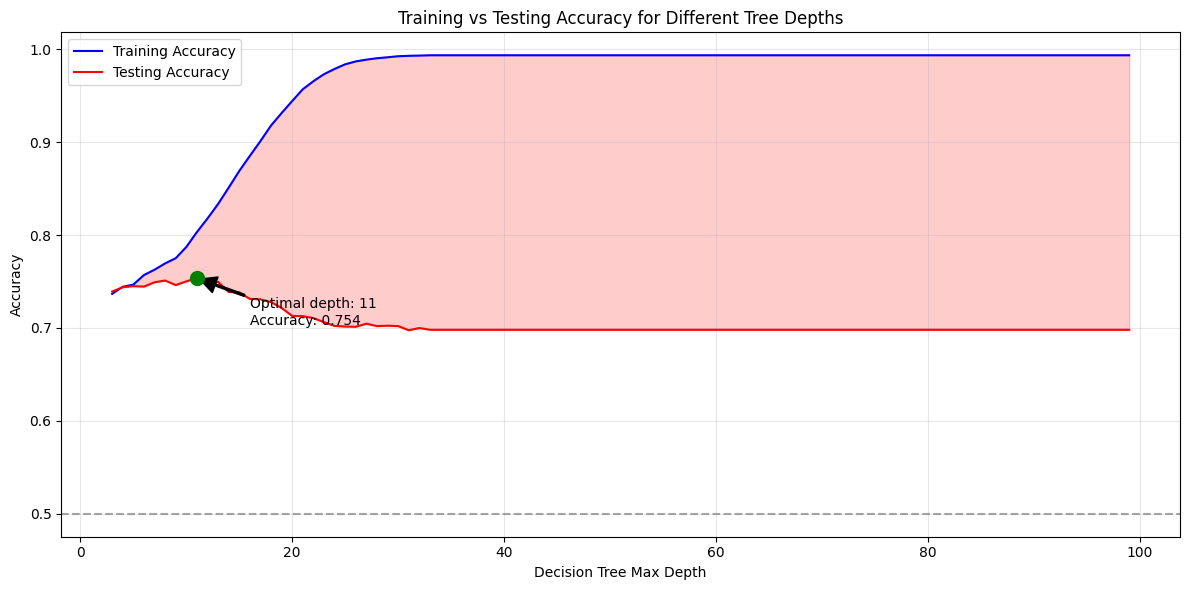

In [47]:

# Lists to store accuracies
depths = list(range(3, 100))
train_accuracies = []
test_accuracies = []

# Loop over different max depths
for i in depths:
    tree_model = DecisionTreeClassifier(max_depth=i, random_state=random_var)
    tree_model.fit(X=X_train, y=y_train)
    
    # Predict and calculate accuracy
    y_pred_test = tree_model.predict(X_test)
    y_pred_train = tree_model.predict(X_train)
    
    train_acc = accuracy_score(y_true=y_train, y_pred=y_pred_train)
    test_acc = accuracy_score(y_true=y_test, y_pred=y_pred_test)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(depths, train_accuracies, label='Training Accuracy', color='blue')
plt.plot(depths, test_accuracies, label='Testing Accuracy', color='red')
plt.xlabel('Decision Tree Max Depth')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy for Different Tree Depths')
plt.legend()
plt.grid(True, alpha=0.3)

# Add a horizontal line showing baseline performance
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Baseline (50%)')

# Add annotation for optimal depth
optimal_depth_index = np.argmax(test_accuracies)
optimal_depth = depths[optimal_depth_index]
optimal_accuracy = test_accuracies[optimal_depth_index]

plt.scatter(optimal_depth, optimal_accuracy, color='green', s=100, zorder=5)
plt.annotate(f'Optimal depth: {optimal_depth}\nAccuracy: {optimal_accuracy:.3f}', 
             xy=(optimal_depth, optimal_accuracy),
             xytext=(optimal_depth+5, optimal_accuracy-0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
             fontsize=10)

# Shade the overfitting region
plt.fill_between(depths, train_accuracies, test_accuracies, 
                 where=(np.array(train_accuracies) > np.array(test_accuracies)), 
                 color='red', alpha=0.2, label='Overfitting region')

plt.tight_layout()
plt.savefig('tree_depth_accuracy_comparison.png', dpi=300)
plt.show()

## 5. Random Forest

In [48]:
rf = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=random_var)

In [49]:
rf.fit(X=X_train, y=y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,3
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False



Plot the first 3 trees in the random forest

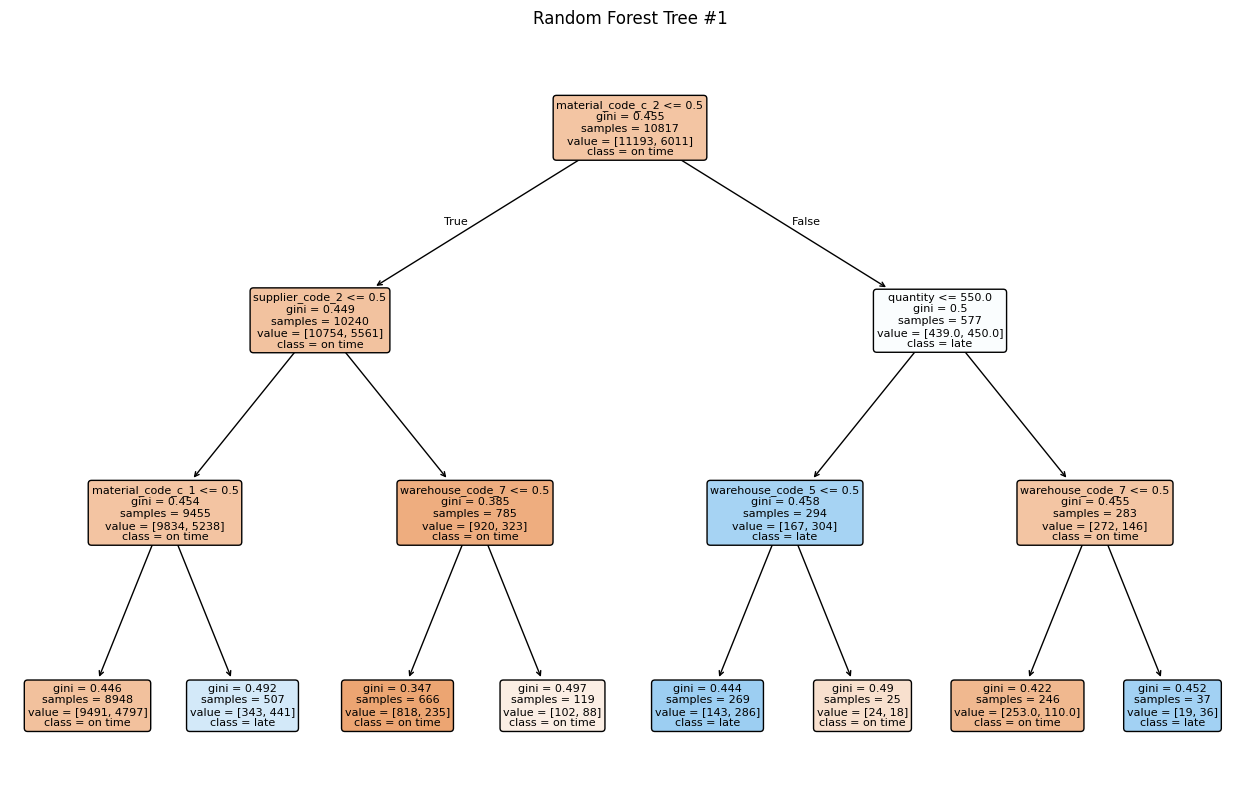

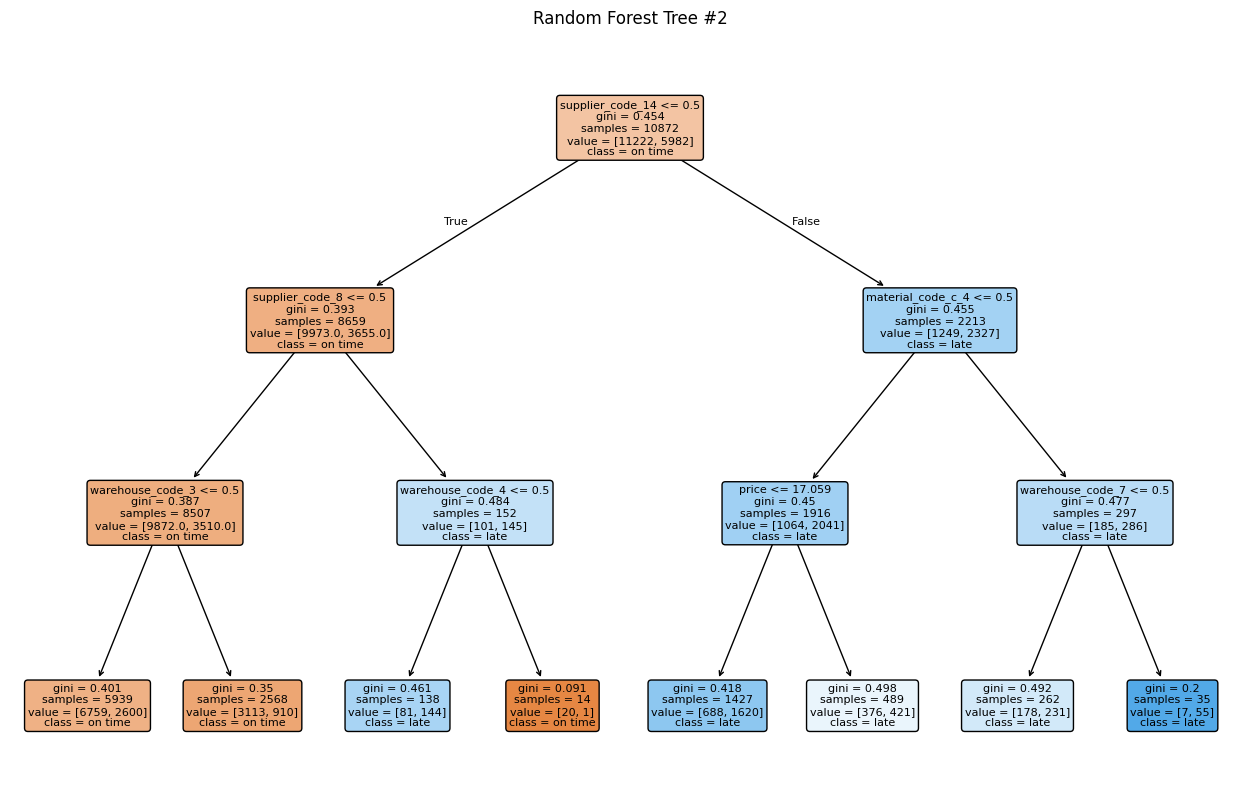

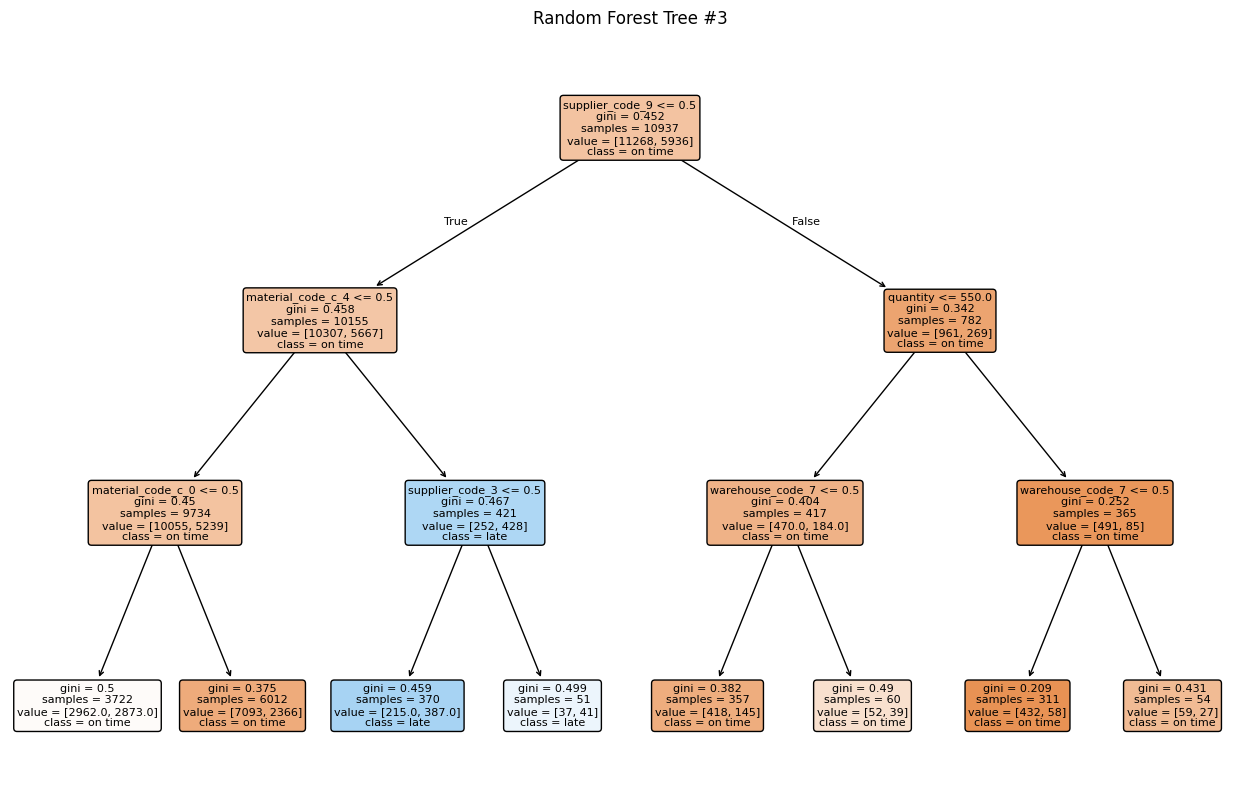

In [50]:

for i in range(3):
    plt.figure(figsize=(16, 10))
    plot_tree(
        rf.estimators_[i],
        feature_names=features,
        class_names=['on time', 'late'],
        filled=True,
        rounded=True,
        max_depth=3  # Optional: limit depth for readability
    )
    plt.title(f"Random Forest Tree #{i+1}")
    plt.show()

In [51]:
rf_pred = rf.predict(X_test)


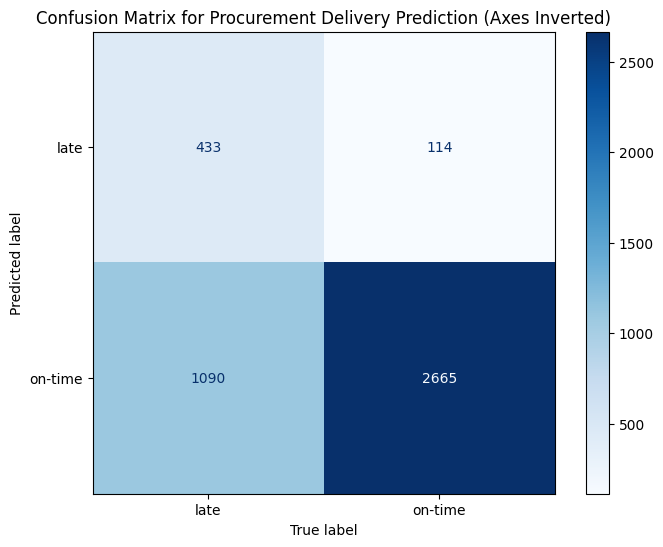

In [52]:
cm = confusion_matrix(y_test, rf_pred, labels=[1, 0])
cm_transposed = cm.T
disp = ConfusionMatrixDisplay(confusion_matrix=cm_transposed, 
                             display_labels=['late', 'on-time'])

# Create a figure and plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.xlabel('True label')  # This will now be on the x-axis
plt.ylabel('Predicted label')  # This will now be on the y-axis
plt.title('Confusion Matrix for Procurement Delivery Prediction (Axes Inverted)')
plt.show()

In [53]:
accuracy_score(y_true=y_test, y_pred=rf_pred)

0.7201301720130172

In [54]:
precision_score(y_true=y_test, y_pred=rf_pred)

0.7915904936014625

In [55]:
recall_score(y_true=y_test, y_pred=rf_pred)

0.2843072882468812

### Overfitting with random forest

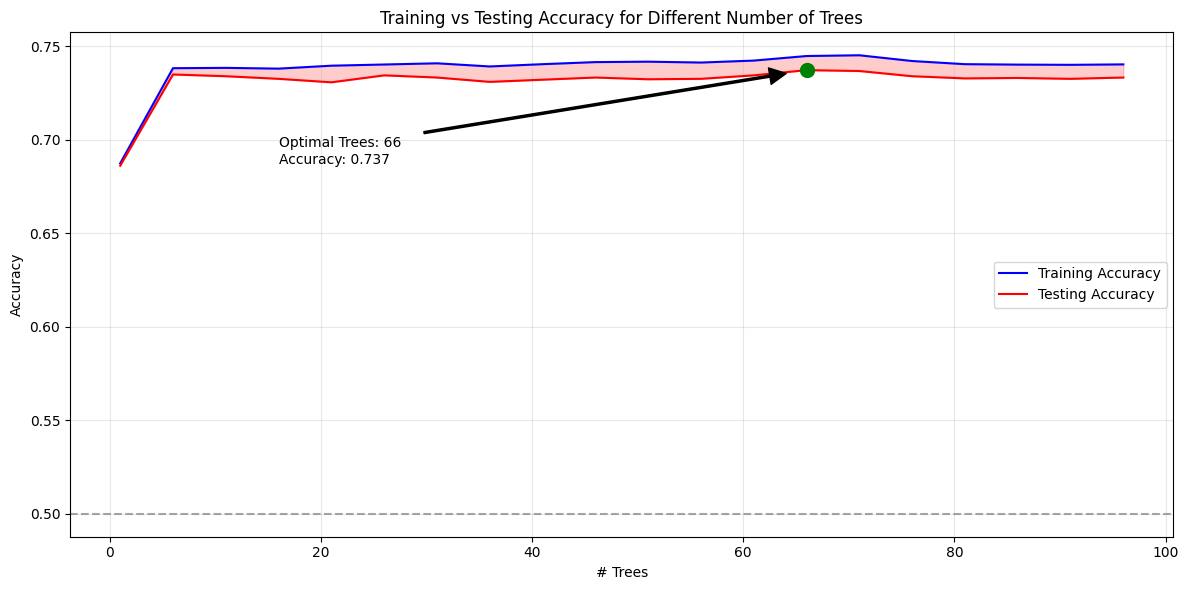

In [56]:

# Lists to store accuracies
trees = list(range(1, 101, 5))
train_accuracies = []
test_accuracies = []

# Loop over different max depths
for i in trees:
    tree_model = RandomForestClassifier(max_depth=5, n_estimators=i, random_state=random_var)
    tree_model.fit(X=X_train, y=y_train)
    
    # Predict and calculate accuracy
    y_pred_test = tree_model.predict(X_test)
    y_pred_train = tree_model.predict(X_train)
    
    train_acc = accuracy_score(y_true=y_train, y_pred=y_pred_train)
    test_acc = accuracy_score(y_true=y_test, y_pred=y_pred_test)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(trees, train_accuracies, label='Training Accuracy', color='blue')
plt.plot(trees, test_accuracies, label='Testing Accuracy', color='red')
plt.xlabel('# Trees')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy for Different Number of Trees')
plt.legend()
plt.grid(True, alpha=0.3)

# Add a horizontal line showing baseline performance
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Baseline (50%)')

# Add annotation for optimal depth
optimal_tree_index = np.argmax(test_accuracies)
optimal_tree = trees[optimal_tree_index]
optimal_accuracy = test_accuracies[optimal_tree_index]

plt.scatter(optimal_tree, optimal_accuracy, color='green', s=100, zorder=5)
plt.annotate(f'Optimal Trees: {optimal_tree}\nAccuracy: {optimal_accuracy:.3f}', 
             xy=(optimal_tree, optimal_accuracy),
             xytext=(optimal_depth+5, optimal_accuracy-0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
             fontsize=10)

# Shade the overfitting region
plt.fill_between(trees, train_accuracies, test_accuracies, 
                 where=(np.array(train_accuracies) > np.array(test_accuracies)), 
                 color='red', alpha=0.2, label='Overfitting region')

plt.tight_layout()
plt.savefig('gbm_accuracy_comparison.png', dpi=300)
plt.show()

## 6. Gradient Boosted Trees

In [57]:
gbm = GradientBoostingClassifier(n_estimators=20, max_depth=5, random_state=random_var)

In [58]:
gbm.fit(X=X_train, y=y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,20
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,5
,min_impurity_decrease,0.0
,init,None


In [59]:
gbm_pred = gbm.predict(X_test)

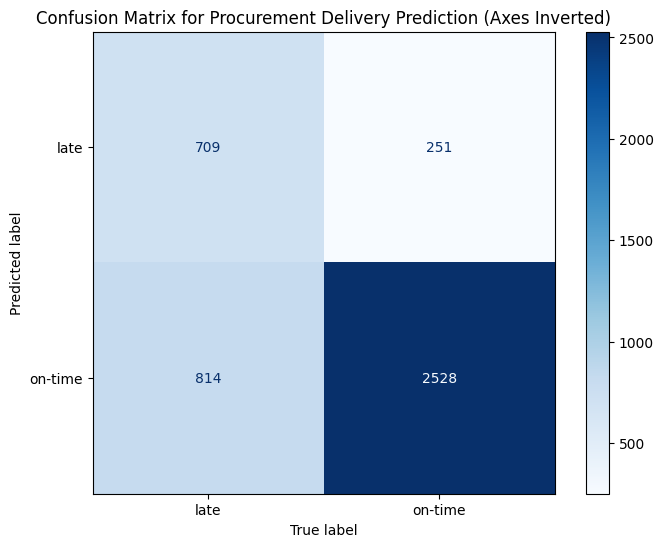

In [60]:
cm = confusion_matrix(y_test, gbm_pred, labels=[1, 0])
cm_transposed = cm.T
disp = ConfusionMatrixDisplay(confusion_matrix=cm_transposed, 
                             display_labels=['late', 'on-time'])

# Create a figure and plot
fig, ax = plt.subplots(figsize=(8, 6))
disp.plot(ax=ax, cmap='Blues')
plt.xlabel('True label')  # This will now be on the x-axis
plt.ylabel('Predicted label')  # This will now be on the y-axis
plt.title('Confusion Matrix for Procurement Delivery Prediction (Axes Inverted)')
plt.show()

In [61]:
accuracy_score(y_true=y_test, y_pred=gbm_pred)


0.7524407252440726

In [62]:
precision_score(y_true=y_test, y_pred=gbm_pred)

0.7385416666666667

In [63]:
recall_score(y_true=y_test, y_pred=gbm_pred)

0.46552856204858833

In [ ]:

# Lists to store accuracies
trees = list(range(10, 201, 20))
train_accuracies = []
test_accuracies = []

# Loop over different max depths
for i in trees:
    tree_model = GradientBoostingClassifier(max_depth=5, n_estimators=i, random_state=random_var)
    tree_model.fit(X=X_train, y=y_train)
    
    # Predict and calculate accuracy
    y_pred_test = tree_model.predict(X_test)
    y_pred_train = tree_model.predict(X_train)
    
    train_acc = accuracy_score(y_true=y_train, y_pred=y_pred_train)
    test_acc = accuracy_score(y_true=y_test, y_pred=y_pred_test)
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(trees, train_accuracies, label='Training Accuracy', color='blue')
plt.plot(trees, test_accuracies, label='Testing Accuracy', color='red')
plt.xlabel('# Trees')
plt.ylabel('Accuracy')
plt.title('Training vs Testing Accuracy for Different Number of Trees')
plt.legend()
plt.grid(True, alpha=0.3)

# Add a horizontal line showing baseline performance
plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.7, label='Baseline (50%)')

# Add annotation for optimal depth
optimal_tree_index = np.argmax(test_accuracies)
optimal_tree = trees[optimal_tree_index]
optimal_accuracy = test_accuracies[optimal_tree_index]

plt.scatter(optimal_tree, optimal_accuracy, color='green', s=100, zorder=5)
plt.annotate(f'Optimal Trees: {optimal_tree}\nAccuracy: {optimal_accuracy:.3f}', 
             xy=(optimal_tree, optimal_accuracy),
             xytext=(optimal_depth+5, optimal_accuracy-0.05),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1.5),
             fontsize=10)

# Shade the overfitting region
plt.fill_between(trees, train_accuracies, test_accuracies, 
                 where=(np.array(train_accuracies) > np.array(test_accuracies)), 
                 color='red', alpha=0.2, label='Overfitting region')

plt.tight_layout()
plt.savefig('gbm_accuracy_comparison.png', dpi=300)
plt.show()